# Double-Well Potential

## Problem Setup

### Potential

$$V(x) = \frac{x^4}{4} - \frac{x^2}{2}$$

### Gradient

$$V'(x) = x^3 - x = x(x^2-1)$$

Stationary points: $V'(x)=0 \Rightarrow x \in \{-1,0,+1\}$.

### Target Boltzmann density

$$\pi_\infty(x) = Z^{-1}\exp\!\left(-\frac{2V(x)}{\sigma^2}\right)$$


## Setup

In [1]:
import numpy as np
import scipy.integrate as sci
import scipy.stats as scs
import matplotlib.pyplot as plt
import time
from math import gamma
from pathlib import Path
from typing import Callable, Tuple

plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})

GLOBAL_SEED = 42
rng = np.random.default_rng(GLOBAL_SEED)

OUT = Path('doublewell_output')
OUT.mkdir(exist_ok=True)

In [2]:
def V(x):
    """V(x) = x^4/4 - x^2/2."""
    return x**4 / 4.0 - x**2 / 2.0

def gradV(x):
    """V'(x) = x^3 - x."""
    return x**3 - x

def hessV(x):
    """V''(x) = 3x^2 - 1."""
    return 3.0 * x**2 - 1.0

def log_pi_unnorm(x, sigma):
    """Unnormalized log pi_inf = -2V(x)/sigma^2."""
    return -2.0 * V(x) / sigma**2

def grad_log_pi(x, sigma):
    """grad log pi_inf = -2 V'(x) / sigma^2."""
    return -2.0 * gradV(x) / sigma**2

def gradU(x, sigma):
    """gradU for pi(x) ∝ exp(-2V(x)/sigma^2): gradU = 2 V'(x) / sigma^2."""
    return -grad_log_pi(x, sigma)

### Target reference sampler

In [3]:
class TargetSampler:
    """Numerical inverse-CDF sampler for pi_inf(x) = Z^{-1} exp(-2V(x)/sigma^2).
    
    This is an unavoidable numerical step: the CDF of pi_inf is not elementary.
    """

    def __init__(self, sigma: float, L: float = 4.0, n_grid: int = 80_000):
        self.sigma = sigma
        self.L = L
        self.n_grid = n_grid
        self._build()

    def _build(self):
        xs = np.linspace(-self.L, self.L, self.n_grid)
        log_p = log_pi_unnorm(xs, self.sigma)
        log_p -= log_p.max()  # numerical stability
        p = np.exp(log_p)
        Z_approx = np.trapezoid(p, xs)
        self._p_norm = p / Z_approx
        # CDF by cumulative trapezoid
        dx = xs[1] - xs[0]
        cdf = np.concatenate([[0.0], np.cumsum(0.5*(self._p_norm[:-1]+self._p_norm[1:])*dx)])
        self.tail_mass = 1.0 - cdf[-1]
        self._xs = xs
        self._cdf = cdf

    def sample(self, n: int, rng_: np.random.Generator) -> np.ndarray:
        """Draw n iid samples from pi_inf by inverse-CDF (numerical)."""
        u = rng_.uniform(0.0, self._cdf[-1], size=n)
        return np.interp(u, self._cdf, self._xs)

    def density(self, x) -> np.ndarray:
        """Normalized density at x by grid interpolation."""
        return np.interp(np.asarray(x), self._xs, self._p_norm)

    def diagnostic(self):
        print(f"TargetSampler: L={self.L}, n_grid={self.n_grid}")
        print(f"  tail mass outside [-{self.L},{self.L}]: {self.tail_mass:.2e}")

## 5.3 Metrics

### W2
$$W_2^2(\hat{\mu}_X,\hat{\mu}_Y) = \frac{1}{N}\sum_i(x_{(i)}-y_{(i)})^2 \quad \text{(exact, via sorting)}$$

### MMD²

Kernel: $k(x,y)=\exp(-(x-y)^2/2h^2)$, bandwidth $h$ is an explicit parameter.

$$\widehat{\mathrm{MMD}}^2_b = \frac{1}{N^2}\sum_{i,j}k(x_i,x_j) - \frac{2}{NM}\sum_{i,j}k(x_i,y_j) + \frac{1}{M^2}\sum_{i,j}k(y_i,y_j)$$

### EMC
$$\mathrm{EMC} = -\frac{p_L\log p_L + p_R\log p_R}{\log 2}$$

In [4]:
def _finite(x: np.ndarray) -> np.ndarray:
    """Return only the finite (non-NaN, non-Inf) entries of x."""
    return x[np.isfinite(x)]


def w2_empirical_1d(x: np.ndarray, y: np.ndarray) -> float:
    """Exact empirical 1D W2 via sorting.

    Filters NaN/Inf before sorting, then subsamples to min(|x|,|y|).
    Returns np.nan if either finite sample is empty.
    """
    xf, yf = _finite(x), _finite(y)
    n = min(len(xf), len(yf))
    if n == 0:
        return float('nan')
    return float(np.sqrt(np.mean((np.sort(xf[:n]) - np.sort(yf[:n]))**2)))


def mmd_squared(x: np.ndarray, y: np.ndarray, h: float) -> float:
    """Biased empirical MMD^2 with Gaussian kernel k(a,b)=exp(-(a-b)^2/(2h^2)).

    Uses the V-statistic (biased) estimator:
        MMD^2_b = (1/N^2) sum_{i,j} k(x_i,x_j)
                - (2/NM)  sum_{i,j} k(x_i,y_j)
                + (1/M^2) sum_{i,j} k(y_i,y_j)

    This equals ||mu_X - mu_Y||_H^2 >= 0 exactly, so it is always non-negative.
    The unbiased U-statistic can be negative for finite N when x ~= y
    (as observed with MALA), because it is not a squared norm — avoid it here.

    Filters NaN/Inf before computing. Returns np.nan if a sample is empty.
    """
    xf, yf = _finite(x), _finite(y)
    if len(xf) < 1 or len(yf) < 1:
        return float('nan')
    h2 = 2.0 * h**2

    Kxx = np.exp(-(xf[:, None] - xf[None, :])**2 / h2).mean()
    Kyy = np.exp(-(yf[:, None] - yf[None, :])**2 / h2).mean()
    Kxy = np.exp(-(xf[:, None] - yf[None, :])**2 / h2).mean()
    return float(Kxx - 2.0 * Kxy + Kyy)


def emc(samples: np.ndarray) -> float:
    """Normalized entropy EMC for double-well (basin: x<0 left, x>0 right).

    NaN/Inf particles are excluded before computing occupancy fractions.
    Without this, NaN comparisons return False for both < 0 and > 0,
    making p_L + p_R < 1 and producing EMC > 1 — a nonsensical result.
    """
    clean = _finite(samples)
    n = len(clean)
    if n == 0:
        return 0.0
    p_L = float(np.sum(clean < 0)) / n
    p_R = float(np.sum(clean > 0)) / n
    xlx = lambda p: 0.0 if p == 0.0 else p * np.log(p)
    return -(xlx(p_L) + xlx(p_R)) / np.log(2)

## Lévy Score Implementation


We use a compound Poisson process with Lévy measure
$\nu(dr) = \tfrac{\lambda}{4}\mathbf{1}_{[-2,2]}(r)\,dr$,
corresponding to jump sizes $A \sim \mathrm{Uniform}(-2,2)$ at rate $\lambda$.

The stationary Lévy score is:

$$S_L^s(x) = -\int_0^1\int_{\mathbb{R}} r\cdot\frac{\pi_\infty(x-\theta r)}{\pi_\infty(x)}\,\nu(dr)\,d\theta$$

Substituting $\nu$ and canceling the $Z$:

$$S_L^s(x) = -\frac{\lambda}{4}\int_0^1\int_{-2}^{2} r\cdot\exp\!\left(-\frac{2}{\sigma^2}(V(x-\theta r)-V(x))\right)dr\,d\theta$$

We thus implement:

$$\boxed{S_L^s(x) = -\frac{\lambda}{4}\int_0^2 (2-u)\Bigl[e^{-(2/\sigma^2)(V(x-u)-V(x))} - e^{-(2/\sigma^2)(V(x+u)-V(x))}\Bigr]du}$$

using 64-point Gauss-Legendre quadrature on $[0,2]$.

In [5]:
# Precompute Gauss-Legendre nodes and weights on [0, 2] once at import time.
_GL_DEG = 64
_gl_nodes_ref, _gl_weights_ref = np.polynomial.legendre.leggauss(_GL_DEG)
# Map [-1,1] -> [0,2]: u = node + 1, Jacobian = 1 (since (b-a)/2 = 1)
_GL_U = _gl_nodes_ref + 1.0   # shape (64,), values in [0, 2]
_GL_W = _gl_weights_ref       # shape (64,)
_SCORE_CLIP = 50.0


def levy_score(x: float, sigma: float, lam: float) -> float:
    """Stationary Lévy score S_L^s(x) at a single point, via Gauss-Legendre.
    
    Unavoidable numerical quadrature: exp(-quartic) has no elementary antiderivative.
    """
    u = _GL_U
    c = -2.0 / sigma**2
    Vx = V(x)
    dVm = V(x - u) - Vx
    dVp = V(x + u) - Vx
    em = np.exp(np.clip(c * dVm, -_SCORE_CLIP, _SCORE_CLIP))
    ep = np.exp(np.clip(c * dVp, -_SCORE_CLIP, _SCORE_CLIP))
    return float(-(lam / 4.0) * np.dot(_GL_W, (2.0 - u) * (em - ep)))


def levy_score_vec(xs: np.ndarray, sigma: float, lam: float) -> np.ndarray:
    """Vectorized S_L^s over array xs. Shape: (N,)."""
    u = _GL_U[None, :]          # (1, 64)
    w = _GL_W[None, :]          # (1, 64)
    x = xs[:, None]             # (N, 1)
    c = -2.0 / sigma**2
    Vx = V(xs)[:, None]         # (N, 1)
    dVm = V(x - u) - Vx
    dVp = V(x + u) - Vx
    em = np.exp(np.clip(c * dVm, -_SCORE_CLIP, _SCORE_CLIP))
    ep = np.exp(np.clip(c * dVp, -_SCORE_CLIP, _SCORE_CLIP))
    return -(lam / 4.0) * (w * (2.0 - u) * (em - ep)).sum(axis=1)


def levy_score_quad_validate(x: float, sigma: float, lam: float) -> float:
    """Validation only: compute S_L^s(x) with scipy.integrate.quad.
    
    Not used in the main experiment (slower). Only for checking GL implementation.
    """
    c = -2.0 / sigma**2
    Vx = V(x)
    integrand = lambda u: (2.0 - u) * (
        np.exp(c * (V(x - u) - Vx)) - np.exp(c * (V(x + u) - Vx))
    )
    result, _ = sci.quad(integrand, 0.0, 2.0, limit=200)
    return -(lam / 4.0) * result

## Samplers

All samplers maintain $N$ independent particles as an array of shape $(N,)$.

### ULA

Euler-Maruyama for $dX = -V'(X)\,dt + \sigma\,dB_t$:
$$X_{n+1} = X_n - V'(X_n)\,dt + \sigma\sqrt{dt}\,\xi_n, \quad \xi_n\sim\mathcal{N}(0,1)$$

### MALA

Proposal: $X^* = X_n + \frac{h}{2}\nabla\log\pi_\infty(X_n) + \sqrt{h}\,\xi_n$

where $\nabla\log\pi_\infty = -2V'/\sigma^2$. Accept with Metropolis ratio:
$$\alpha = \frac{\pi_\infty(X^*)\,q(X_n|X^*)}{\pi_\infty(X_n)\,q(X^*|X_n)}$$

### FLMC (aka $c_\alpha$ algorithm)

$$X_{n+1} = X_n - dt\cdot c_\alpha\cdot V'(X_n) + dt^{1/\alpha}\,\xi_n^{(\alpha)}$$

where $\xi_n^{(\alpha)}\sim S\alpha S(1)$ (symmetric $\alpha$-stable, scale 1) and $c_\alpha=1$ (explicit convention).

Chambers-Mallows-Stuck sampler for $S\alpha S(1)$:
$$\phi\sim U(-\pi/2,\pi/2),\quad W\sim\mathrm{Exp}(1): \quad
\xi = \frac{\sin(\alpha\phi)}{\cos(\phi)^{1/\alpha}}\cdot\left(\frac{\cos((1-\alpha)\phi)}{W}\right)^{(1-\alpha)/\alpha}$$

### LSB-MC

Discretization of $dZ = (-V'(Z)+S_L^s(Z))\,dt + \sigma\,dB_t + dL_t$:

$$Z_{n+1} = Z_n + \underbrace{(-V'(Z_n)+S_L^s(Z_n))\,dt}_{\text{total drift}} + \sigma\sqrt{dt}\,\xi_n + \underbrace{\sum_{k=1}^{N_n}A_k}_{\text{compound Poisson}}$$

- $N_n\sim\mathrm{Poisson}(\lambda\,dt)$
- $A_k\sim\mathrm{Uniform}(-2,2)$ iid (symmetric)
- $\xi_n\sim\mathcal{N}(0,1)$

In [6]:
# ──────────────────────────────────────────
# ULA
# ──────────────────────────────────────────

def step_ula(x: np.ndarray, dt: float, sigma: float, rng_: np.random.Generator) -> np.ndarray:
    """ULA: X <- X - V'(X)*dt + sigma*sqrt(dt)*N(0,1)."""
    return x - gradV(x) * dt + sigma * np.sqrt(dt) * rng_.standard_normal(len(x))


# ──────────────────────────────────────────
# MALA
# ──────────────────────────────────────────

def step_mala(x: np.ndarray, dt: float, sigma: float,
              rng_: np.random.Generator) -> Tuple[np.ndarray, float]:
    """MALA targeting pi_inf. Returns (new_x, acceptance_rate)."""
    glp_cur = grad_log_pi(x, sigma)
    xi = rng_.standard_normal(len(x))
    x_prop = x + 0.5 * dt * glp_cur + np.sqrt(dt) * xi

    log_pi_cur  = log_pi_unnorm(x,      sigma)
    log_pi_prop = log_pi_unnorm(x_prop, sigma)

    glp_prop = grad_log_pi(x_prop, sigma)
    mu_fwd = x      + 0.5 * dt * glp_cur
    mu_rev = x_prop + 0.5 * dt * glp_prop
    log_q_fwd = -0.5 * ((x_prop - mu_fwd)**2) / dt
    log_q_rev = -0.5 * ((x      - mu_rev)**2) / dt

    log_alpha = (log_pi_prop + log_q_rev) - (log_pi_cur + log_q_fwd)
    accept = np.log(rng_.uniform(size=len(x))) < log_alpha
    return np.where(accept, x_prop, x), float(accept.mean())


# ──────────────────────────────────────────
# Stabilized approximate FLA / FLMC  (Simsekli et al. 2017, Sec. 3.3)
# ──────────────────────────────────────────

# The active benchmark uses the approximate FLA drift with practical drift
# taming and clipped S_alpha_S(1) noise for numerical stability.
FLMC_XI_CLIP = 100.0

def c_alpha_paper(alpha: float) -> float:
    """Simsekli et al. approximate FLA constant Gamma(alpha-1)/Gamma(alpha/2)^2."""
    if not (1.0 < alpha <= 2.0):
        raise ValueError(f"alpha must satisfy 1 < alpha <= 2, got {alpha}")
    return gamma(alpha - 1.0) / (gamma(alpha / 2.0) ** 2)


def _sample_sas(rng_: np.random.Generator, n: int, alpha: float) -> np.ndarray:
    """Sample n iid S_alpha_S(1), with characteristic function exp(-|omega|^alpha)."""
    if not (1.0 < alpha <= 2.0):
        raise ValueError(f"alpha must satisfy 1 < alpha <= 2, got {alpha}")
    if np.isclose(alpha, 2.0):
        return np.sqrt(2.0) * rng_.standard_normal(size=n)
    phi = rng_.uniform(-np.pi / 2.0, np.pi / 2.0, size=n)
    w   = rng_.exponential(1.0, size=n)
    num  = np.sin(alpha * phi)
    den  = np.cos(phi)**(1.0 / alpha)
    tail = (np.cos((1.0 - alpha) * phi) / w)**((1.0 - alpha) / alpha)
    return (num / den) * tail


def step_fla(x: np.ndarray, dt: float, sigma: float, alpha: float,
                               rng_: np.random.Generator) -> np.ndarray:

    xi = np.clip(_sample_sas(rng_, len(x), alpha), -FLMC_XI_CLIP, FLMC_XI_CLIP)
    raw_drift = -c_alpha_paper(alpha) * gradU(x, sigma)
    tamed_drift = raw_drift / (1.0 + dt * np.abs(raw_drift))
    return x + dt * tamed_drift + dt**(1.0 / alpha) * xi


# ──────────────────────────────────────────
# LSB-MC
# ──────────────────────────────────────────

def step_lsbmc(x: np.ndarray, dt: float, sigma: float, lam: float,
               rng_: np.random.Generator) -> np.ndarray:
    """LSB-MC: tamed drift + Brownian noise + compound Poisson jumps.

    Total raw drift = -V'(x) + S_L^s(x).
    Tamed drift     = raw_drift / (1 + dt * |raw_drift|).
    Jumps A_k ~ Uniform(-2, 2) (symmetric — see Section 6.1).
    """
    N = len(x)
    score     = levy_score_vec(x, sigma, lam)       # (N,) — numerical quadrature
    raw_drift = -gradV(x) + score                   # total raw drift
    tamed     = raw_drift / (1.0 + dt * np.abs(raw_drift))   # tamed
    bm        = sigma * np.sqrt(dt) * rng_.standard_normal(N)

    # Compound Poisson: N_i ~ Poisson(lam*dt), A_k ~ Uniform(-2, 2)
    n_jumps = rng_.poisson(lam * dt, size=N)
    jump_total = np.zeros(N)
    for i in np.where(n_jumps > 0)[0]:
        jump_total[i] = rng_.uniform(-2.0, 2.0, size=n_jumps[i]).sum()

    return x + tamed * dt + bm + jump_total

## Main Experiment

In [7]:
# ── Shared parameters ─────────────────────────────────────────────────
SIGMA        = 0.5
DT           = 0.01
N_PART       = 2000
T_TOTAL      = 20.0
N_STEPS      = int(T_TOTAL / DT)
RECORD_EVERY = 20      # record metrics every this many steps
LAM          = 1.0     # LSB-MC jump rate
ALPHA_FLMC   = 1.5     # FLMC stability index
MMD_H        = 0.5     # MMD bandwidth
N_REF        = 5000    # target reference sample size

print(f"T={T_TOTAL}, dt={DT}, steps={N_STEPS}, particles={N_PART}")
print(f"sigma={SIGMA}, lambda={LAM}, alpha_FLMC={ALPHA_FLMC}, c_alpha={c_alpha_paper(ALPHA_FLMC):.6f}")
print(f"MMD bandwidth h={MMD_H}")

T=20.0, dt=0.01, steps=2000, particles=2000
sigma=0.5, lambda=1.0, alpha_FLMC=1.5, c_alpha=1.180341
MMD bandwidth h=0.5


In [8]:
# Build target sampler and reference sample
target = TargetSampler(sigma=SIGMA, L=4.0, n_grid=80_000)
target.diagnostic()

x_ref = target.sample(N_REF, np.random.default_rng(GLOBAL_SEED + 1))
print(f"\nReference sample: N={N_REF}, mean={x_ref.mean():.4f}, "
      f"frac_left={np.mean(x_ref<0):.4f} (expected ~0.5)")

TargetSampler: L=4.0, n_grid=80000
  tail mass outside [-4.0,4.0]: 2.14e-12

Reference sample: N=5000, mean=-0.0014, frac_left=0.4996 (expected ~0.5)


In [9]:
def run_experiment(name, step_fn, x0, rng_exp):
    """Run sampler, record W2/MMD/EMC/E[x^2] every RECORD_EVERY steps."""
    x = x0.copy()
    times, w2s, mmds, emcs, ex2s = [], [], [], [], []
    t0 = time.time()
    for step in range(N_STEPS):
        x = step_fn(x, rng_exp)
        if (step + 1) % RECORD_EVERY == 0:
            times.append((step + 1) * DT)
            w2s.append(w2_empirical_1d(x, x_ref))
            mmds.append(mmd_squared(x, x_ref, MMD_H))
            emcs.append(emc(x))
            xf = _finite(x)
            ex2s.append(float(np.mean(xf**2)) if len(xf) > 0 else float('nan'))
    elapsed = time.time() - t0
    print(f"{name:8s}: {elapsed:5.1f}s | "
          f"W2={w2s[-1]:.4f}, MMD^2={mmds[-1]:.5f}, EMC={emcs[-1]:.4f}, "
          f"E[x^2]={ex2s[-1]:.4f}")
    return (np.array(times), np.array(w2s), np.array(mmds),
            np.array(emcs), np.array(ex2s), x.copy())


# True E[x^2] under pi_inf: int x^2 pi_inf(x) dx  (numerical)
_true_ex2 = float(np.trapezoid(target._xs**2 * target._p_norm, target._xs))
print(f"True E[x^2] under pi_inf: {_true_ex2:.6f}\n")

x0 = np.random.default_rng(GLOBAL_SEED + 2).normal(-1.0, 0.05, size=N_PART)
print(f"Initial condition: mean={x0.mean():.3f}, std={x0.std():.3f}\n")

results = {}

results['ULA'] = run_experiment(
    'ULA',
    lambda x, r: step_ula(x, DT, SIGMA, r),
    x0, np.random.default_rng(GLOBAL_SEED + 10)
)
results['MALA'] = run_experiment(
    'MALA',
    lambda x, r: step_mala(x, DT, SIGMA, r)[0],
    x0, np.random.default_rng(GLOBAL_SEED + 20)
)
results['FLMC'] = run_experiment(
    'FLMC',
    lambda x, r: step_fla(x, DT, SIGMA, ALPHA_FLMC, r),
    x0, np.random.default_rng(GLOBAL_SEED + 30)
)
results['LSB-MC'] = run_experiment(
    'LSB-MC',
    lambda x, r: step_lsbmc(x, DT, SIGMA, LAM, r),
    x0, np.random.default_rng(GLOBAL_SEED + 40)
)

True E[x^2] under pi_inf: 0.852136

Initial condition: mean=-0.999, std=0.049

ULA     :  34.3s | W2=0.4896, MMD^2=0.04862, EMC=0.9097, E[x^2]=0.8432
MALA    :  34.6s | W2=0.0389, MMD^2=0.00028, EMC=0.9999, E[x^2]=0.8430
FLMC    :  40.1s | W2=0.1426, MMD^2=0.00628, EMC=0.9997, E[x^2]=0.9612
LSB-MC  :  46.5s | W2=0.0593, MMD^2=0.00160, EMC=0.9992, E[x^2]=0.8176


## Visualizations

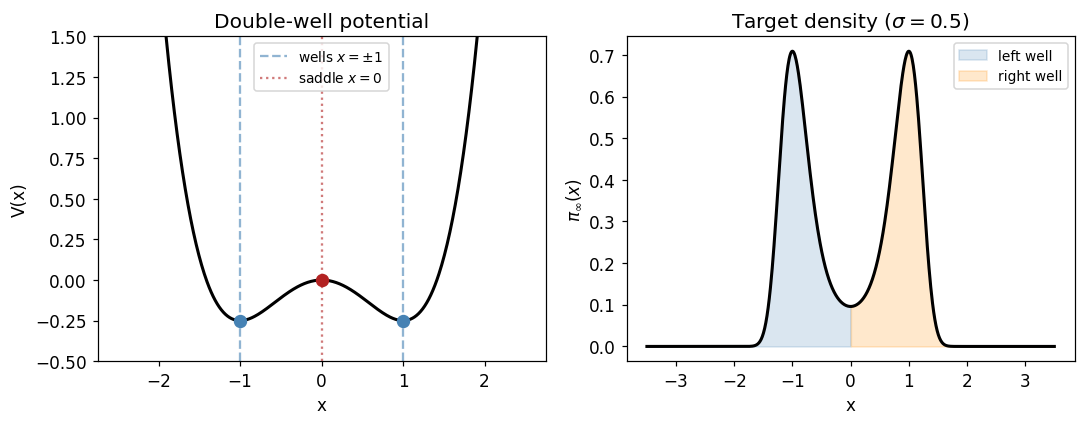

Saved to doublewell_output/doublewell_setup.{pdf,png}


In [10]:
# ── Figure 1: potential and target density ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
xs_p = np.linspace(-2.5, 2.5, 600)

ax = axes[0]
ax.plot(xs_p, V(xs_p), 'k-', lw=2)
ax.axvline(-1, color='steelblue', ls='--', alpha=0.6, label='wells $x=\\pm1$')
ax.axvline(+1, color='steelblue', ls='--', alpha=0.6)
ax.axvline( 0, color='firebrick', ls=':', alpha=0.6, label='saddle $x=0$')
ax.scatter([-1,1], [V(-1),V(1)], c='steelblue', zorder=5, s=60)
ax.scatter([0], [V(0)], c='firebrick', zorder=5, s=60)
ax.set(xlabel='x', ylabel='V(x)', title='Double-well potential')
ax.legend(fontsize=9); ax.set_ylim(-0.5, 1.5)

ax = axes[1]
xs_d = np.linspace(-3.5, 3.5, 700)
pi_v = target.density(xs_d)
ax.plot(xs_d, pi_v, 'k-', lw=2)
ax.fill_between(xs_d[xs_d<0], pi_v[xs_d<0], alpha=0.2, color='steelblue', label='left well')
ax.fill_between(xs_d[xs_d>0], pi_v[xs_d>0], alpha=0.2, color='darkorange', label='right well')
ax.set(xlabel='x', ylabel='$\\pi_\\infty(x)$', title=f'Target density ($\\sigma={SIGMA}$)')
ax.legend(fontsize=9)

plt.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(OUT / f'doublewell_setup.{ext}', bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved to {OUT}/doublewell_setup.{{pdf,png}}")

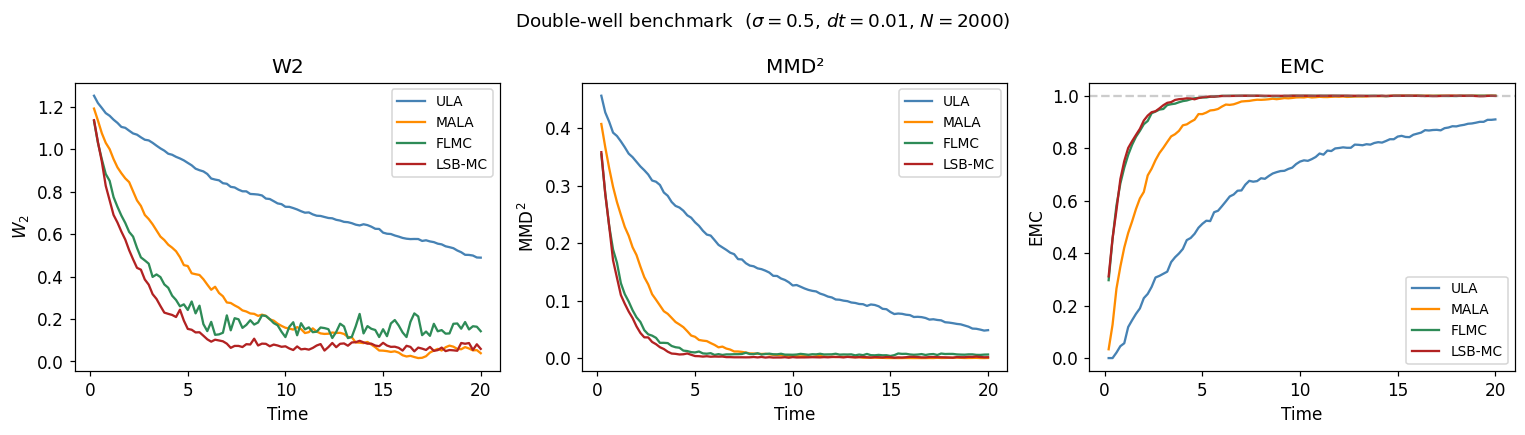

Saved to doublewell_output/doublewell_metrics.{pdf,png}


In [11]:
# ── Figure 2: metric curves ─────────────────────────────────────────
COLORS  = {'ULA':'steelblue','MALA':'darkorange','FLMC':'seagreen','LSB-MC':'firebrick'}
METHODS = ['ULA','MALA','FLMC','LSB-MC']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for m in METHODS:
    t, w2, mmd, em, ex2, _ = results[m]
    axes[0].plot(t, w2,  color=COLORS[m], lw=1.5, label=m)
    axes[1].plot(t, mmd, color=COLORS[m], lw=1.5, label=m)
    axes[2].plot(t, em,  color=COLORS[m], lw=1.5, label=m)

axes[0].set(xlabel='Time', ylabel='$W_2$',     title='W2')
axes[1].set(xlabel='Time', ylabel='MMD$^2$',   title='MMD²')
axes[2].set(xlabel='Time', ylabel='EMC',       title='EMC')
axes[2].axhline(1.0, color='gray', ls='--', alpha=0.4)
for ax in axes: ax.legend(fontsize=9)

plt.suptitle(f'Double-well benchmark  ($\\sigma={SIGMA}$, $dt={DT}$, $N={N_PART}$)', fontsize=12)
plt.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(OUT / f'doublewell_metrics.{ext}', bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved to {OUT}/doublewell_metrics.{{pdf,png}}")

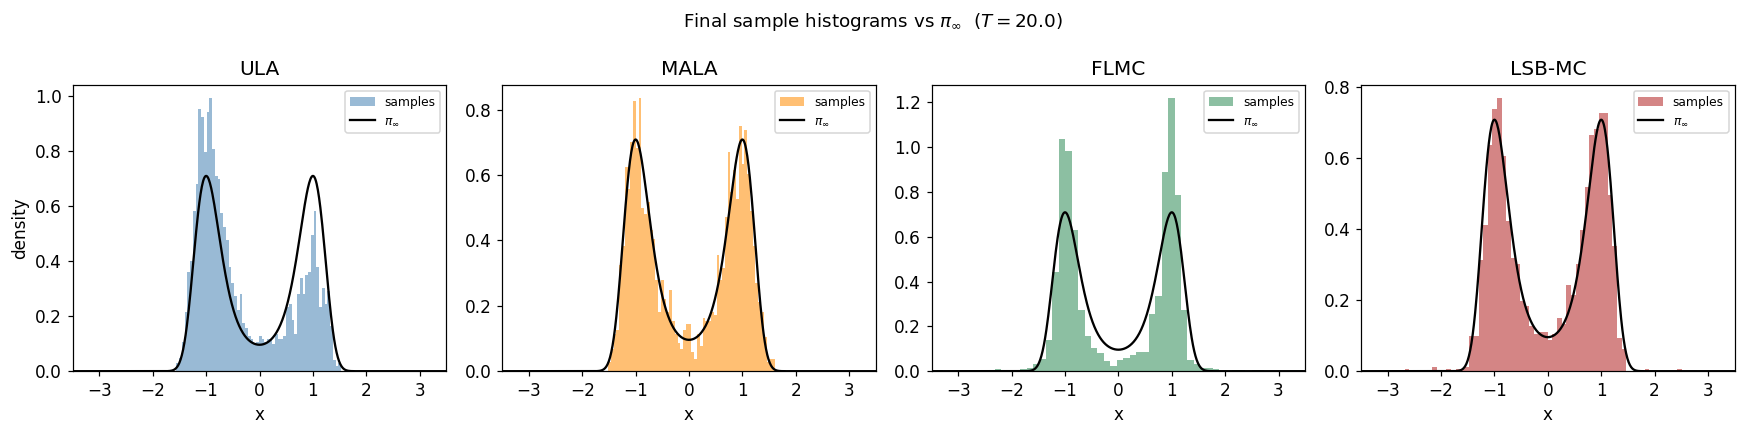

Saved to doublewell_output/doublewell_final_density.{pdf,png}


In [12]:
# ── Figure 3: final sample histograms ──────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)
xs_d = np.linspace(-3.5, 3.5, 600)
pi_v = target.density(xs_d)

for ax, m in zip(axes, METHODS):
    _, _, _, _, _, x_fin = results[m]
    ax.hist(x_fin, bins=60, density=True, alpha=0.55, color=COLORS[m], label='samples')
    ax.plot(xs_d, pi_v, 'k-', lw=1.5, label='$\\pi_\\infty$')
    ax.set(title=m, xlabel='x', xlim=(-3.5, 3.5))
    ax.legend(fontsize=8)

axes[0].set_ylabel('density')
plt.suptitle(f'Final sample histograms vs $\\pi_\\infty$  ($T={T_TOTAL}$)', fontsize=12)
plt.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(OUT / f'doublewell_final_density.{ext}', bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved to {OUT}/doublewell_final_density.{{pdf,png}}")

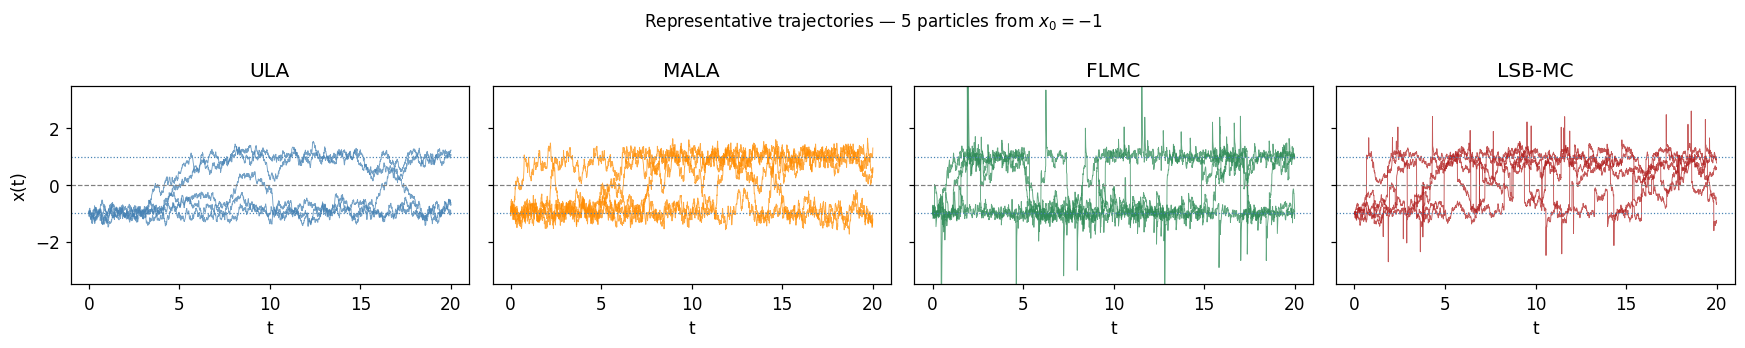

Saved to doublewell_output/doublewell_trajectories.{pdf,png}


In [13]:
# ── Figure 4: representative trajectories ──────────────────────────
N_TRAJ = 5
fig, axes = plt.subplots(1, 4, figsize=(16, 3.2), sharey=True)
t_arr = np.arange(N_STEPS + 1) * DT

step_fns_traj = {
    'ULA':    lambda x, r: step_ula(x, DT, SIGMA, r),
    'MALA':   lambda x, r: step_mala(x, DT, SIGMA, r)[0],
    'FLMC':   lambda x, r: step_fla(x, DT, SIGMA, ALPHA_FLMC, r),
    'LSB-MC': lambda x, r: step_lsbmc(x, DT, SIGMA, LAM, r),
}

for ax, m in zip(axes, METHODS):
    rng_t = np.random.default_rng(GLOBAL_SEED + 300 + METHODS.index(m))
    x = np.full(N_TRAJ, -1.0)
    track = [x.copy()]
    fn = step_fns_traj[m]
    for _ in range(N_STEPS):
        x = fn(x, rng_t)
        track.append(x.copy())
    track = np.array(track)  # (N_STEPS+1, N_TRAJ)
    for j in range(N_TRAJ):
        ax.plot(t_arr, track[:, j], lw=0.6, alpha=0.75, color=COLORS[m])
    ax.axhline(0,  color='gray',      ls='--', lw=0.8)
    ax.axhline(-1, color='steelblue', ls=':', lw=0.8)
    ax.axhline(+1, color='steelblue', ls=':', lw=0.8)
    ax.set(title=m, xlabel='t', ylim=(-3.5, 3.5))

axes[0].set_ylabel('x(t)')
plt.suptitle(f'Representative trajectories — 5 particles from $x_0=-1$', fontsize=11)
plt.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(OUT / f'doublewell_trajectories.{ext}', bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved to {OUT}/doublewell_trajectories.{{pdf,png}}")

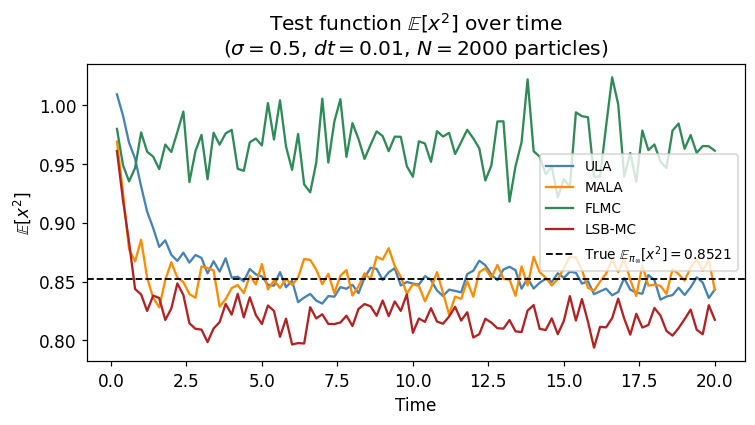

Saved to doublewell_output/doublewell_ex2.{pdf,png}
True E[x^2] = 0.852136
  ULA      final E[x^2] = 0.843151  (error -0.008985)
  MALA     final E[x^2] = 0.843047  (error -0.009089)
  FLMC     final E[x^2] = 0.961197  (error +0.109061)
  LSB-MC   final E[x^2] = 0.817607  (error -0.034529)


In [14]:
# ── Figure 5: E[x^2] as a test function ────────────────────────────
# The true value E_pi[x^2] = int x^2 pi_inf(x) dx is computed numerically
# from the TargetSampler grid and shown as a dashed reference line.

fig, ax = plt.subplots(figsize=(7, 4))

for m in METHODS:
    t, _, _, _, ex2, _ = results[m]
    ax.plot(t, ex2, color=COLORS[m], lw=1.5, label=m)

ax.axhline(_true_ex2, color='black', ls='--', lw=1.2,
           label=f'True $\\mathbb{{E}}_{{\\pi_\\infty}}[x^2] = {_true_ex2:.4f}$')

ax.set(xlabel='Time', ylabel='$\\mathbb{E}[x^2]$',
       title=f'Test function $\\mathbb{{E}}[x^2]$ over time\n'
             f'($\\sigma={SIGMA}$, $dt={DT}$, $N={N_PART}$ particles)')
ax.legend(fontsize=9)

plt.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(OUT / f'doublewell_ex2.{ext}', bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved to {OUT}/doublewell_ex2.{{pdf,png}}")
print(f"True E[x^2] = {_true_ex2:.6f}")
for m in METHODS:
    final_ex2 = results[m][4][-1]
    print(f"  {m:8s} final E[x^2] = {final_ex2:.6f}  (error {final_ex2 - _true_ex2:+.6f})")

## MA-LSBMC: Metropolis-Adjusted LSBMC

---

### Target and existing LSBMC proposal drift

The target is $\pi(x) \propto \exp(-2V(x)/\sigma^2)$ with $V(x) = \tfrac{1}{4}x^4 - \tfrac{1}{2}x^2$.

The existing LSBMC proposal drift is
$$b(x) := -V'(x) + S_L^s(x).$$
Define:
$$\mu(x) := x + \Delta t\, b(x), \qquad \tau = \sigma\sqrt{\Delta t}.$$

---

### Compound-Poisson jump proposal

$$Y = \mu(x) + \tau\,\xi + J, \quad \xi \sim \mathcal{N}(0,1),$$
$$J = \sum_{k=1}^{N} A_k, \quad N \sim \mathrm{Poisson}(\Lambda),\; \Lambda = \lambda\Delta t, \quad A_k \overset{\mathrm{iid}}{\sim} \mathrm{Uniform}(-2,2).$$


---

### Metropolis–Hastings correction

$$\alpha(x,y) = 1 \wedge \frac{\pi(y)\,q(x \mid y)}{\pi(x)\,q(y \mid x)}, \qquad \log r = \log\pi_{\mathrm{unnorm}}(y) - \log\pi_{\mathrm{unnorm}}(x) + \log\tilde{q}(x\mid y) - \log\tilde{q}(y\mid x).$$

The main challenge is computing $q(y \mid x)$, the proposal density, which is no longer Gaussian.

---

### Exact series for $q(y \mid x)$

Let $z = y - \mu(x)$. Then $Z = \tau\xi + J$ and:
$$q(y \mid x) = \sum_{n=0}^{\infty} e^{-\Lambda}\frac{\Lambda^n}{n!}\,\psi_n(z),$$
$$\psi_0(z) = \phi_\tau(z) = \frac{1}{\sqrt{2\pi}\tau}e^{-z^2/(2\tau^2)}, \qquad \psi_n(z) = \int_{-2n}^{2n}\phi_\tau(z-s)\,g_n(s)\,ds \quad (n \ge 1),$$
where $g_n$ is the density of $S_n = A_1 + \cdots + A_n$ with $A_i \sim \mathrm{Uniform}(-2,2)$.

---

### Density of sum of $n$ uniform $(-2,2)$ jumps via Irwin–Hall

Write $A_i = 4U_i - 2$, $U_i \sim U(0,1)$, so $S_n = 4T_n - 2n$ where $T_n = \sum U_i$ has the Irwin–Hall density:
$$h_n(t) = \frac{1}{(n-1)!}\sum_{k=0}^{\lfloor t\rfloor}(-1)^k\binom{n}{k}(t-k)^{n-1}, \quad t \in [0,n].$$
By change of variables $s = 4t - 2n$:
$$g_n(s) = \tfrac{1}{4}\,h_n\!\left(\tfrac{s+2n}{4}\right), \quad s \in [-2n,\,2n].$$

**Sanity check** ($n=1$): $g_1(s) = \tfrac{1}{4}\mathbf{1}_{[-2,2]}(s)$, giving
$\psi_1(z) = \tfrac{1}{4}[\Phi((z+2)/\tau) - \Phi((z-2)/\tau)]$.

---

### Practical numerical approximation

The infinite series above is **mathematically exact** but cannot be summed to infinity. In code we use:
$$\tilde{q}(y \mid x) = \sum_{n=0}^{N_{\max}} e^{-\Lambda}\frac{\Lambda^n}{n!}\,\psi_n(y-\mu(x)),$$
where $N_{\max}$ satisfies $\mathbb{P}(N > N_{\max}) < \varepsilon_{\mathrm{tail}}$.

Each $\psi_n(z)$ for $n \ge 1$ is evaluated by **deterministic Gauss–Legendre quadrature** (not Monte Carlo).

Therefore the implemented MA-LSBMC uses two numerical approximations:
1. **Poisson truncation** at $N_{\max}$ (tail below tolerance $\varepsilon_{\mathrm{tail}}$).
2. **Numerical quadrature** for each Gaussian-convolution term.

The practical acceptance ratio is $\tilde{\alpha}(x,y) = 1 \wedge e^{\log r}$ with $\tilde{q}$ in place of $q$. **Unless the infinite series is evaluated exactly, MA-LSBMC is not an exact MH kernel for $\pi$.**

---

### Acceptance-rate interpretation

| Method | Mixing | Bias reduction |
|--------|--------|----------------|
| LSBMC  | Aggressive cross-well jumps | Discretization bias $O(\Delta t)$ |
| MA-LSBMC | May reject large jumps → slower mixing | Controlled by $\varepsilon_{\mathrm{tail}}$ + quadrature |

Always report acceptance rate alongside W2 / MMD / EMC.

In [15]:
"""
MA-LSBMC helper functions: proposal density q(y|x).

The proposal density is an exact Poisson mixture:
    q(y|x) = sum_{n=0}^inf  exp(-Lambda) * Lambda^n/n!  * psi_n(y - mu(x))

where psi_0 = phi_tau (Gaussian) and psi_n = phi_tau * g_n (convolution with
the density of n iid Uniform(-2,2) jumps).

In code we truncate at N_max chosen so that P(Poisson > N_max) < eps_tail,
and evaluate each psi_n by Gauss-Hermite quadrature (NOT fixed-interval GL).

WHY GAUSS-HERMITE, NOT GL:
  tau = sigma*sqrt(dt) = 0.05 is small.  phi_tau(z-s) has width 0.05, but
  the jump support is [-2,2] (width 4).  Fixed-interval GL nodes are spaced
  ~4/32 = 0.125 apart — 2.5x the Gaussian width — so the peak is missed.
  Gauss-Hermite places nodes relative to tau, resolving phi_tau at any scale.

NUMERICAL HONESTY: the implemented log-density log_q_tilde is a controlled
numerical approximation to log q.  MA-LSBMC is therefore not an exact MH
kernel for pi unless the full infinite series is used.
"""

from math import comb, factorial
from scipy.special import ndtr as _Phi   # standard normal CDF (fast C impl)

# ── Gauss-Hermite nodes for the convolution  psi_n(z) = int phi_tau(z-s) g_n(s) ds
# The substitution s = z - sqrt(2)*tau*t transforms the integral to the standard
# Gauss-Hermite form:  int e^{-t^2} f(t) dt ~ sum_j w_j f(t_j).
# This adapts automatically to any tau, unlike fixed-interval Gauss-Legendre.
_GH_DEG = 64
_gh_nodes, _gh_weights = np.polynomial.hermite.hermgauss(_GH_DEG)


# ─────────────────────────────────────────────────────────────────────────────
# Basic densities
# ─────────────────────────────────────────────────────────────────────────────

def normal_pdf_1d(z: np.ndarray, tau: float) -> np.ndarray:
    """Gaussian density phi_tau(z) = N(0, tau^2) evaluated at z."""
    return np.exp(-0.5 * (z / tau)**2) / (np.sqrt(2.0 * np.pi) * tau)


def log_normal_pdf_1d(z: np.ndarray, tau: float) -> np.ndarray:
    """Log Gaussian density log phi_tau(z)."""
    return -0.5 * (z / tau)**2 - np.log(tau) - 0.5 * np.log(2.0 * np.pi)


# ─────────────────────────────────────────────────────────────────────────────
# Irwin-Hall density and sum-of-uniforms density
# ─────────────────────────────────────────────────────────────────────────────

def irwin_hall_pdf(t: np.ndarray, n: int) -> np.ndarray:
    """Standard Irwin-Hall density h_n(t) for T_n = U_1+...+U_n, U_i ~ U(0,1).

    h_n(t) = 1/(n-1)! * sum_{k=0}^{floor(t)} (-1)^k * C(n,k) * (t-k)^{n-1}
    for t in [0, n]; zero outside.

    Uses exact combinatorial formula (piecewise polynomial of degree n-1).

    NOTE on boundary: uses diff >= 0 (not diff > 0) so that (t-k)^0 = 1 is
    correctly included when t == k for n=1.  For n>1, (t-k)^{n-1} = 0 when
    diff=0, so the change is harmless in those cases.
    """
    t = np.atleast_1d(np.asarray(t, dtype=float))
    out = np.zeros_like(t)
    mask = (t >= 0) & (t <= n)
    if not np.any(mask):
        return out
    t_m = t[mask]
    inv_fact = 1.0 / factorial(n - 1) if n >= 1 else 1.0
    for k in range(n):
        diff = t_m - k
        # >= 0 (not > 0): for n=1, diff=0 gives 0^0=1, which is the correct
        # Uniform(0,1) density value at the left boundary.
        contrib = ((-1)**k) * comb(n, k) * np.where(diff >= 0, diff**(n - 1), 0.0)
        out[mask] += contrib
    out[mask] *= inv_fact
    out[out < 0] = 0.0  # numerical floor (rounding near interval edges)
    return out


def sum_uniform_pdf_1d(s: np.ndarray,
                        n: int,
                        jump_low: float = -2.0,
                        jump_high: float = 2.0) -> np.ndarray:
    """Density g_n of S_n = A_1+...+A_n, A_i ~ Uniform(jump_low, jump_high).

    Uses the Irwin-Hall transform:
        A_i = (jump_high - jump_low)*U_i + jump_low,  U_i ~ U(0,1)
        S_n = (jump_high - jump_low)*T_n + n*jump_low
    so  g_n(s) = h_n((s - n*jump_low)/(jump_high - jump_low))
                 / (jump_high - jump_low)
    where h_n is the standard Irwin-Hall density.

    For Uniform(-2,2): jump_low=-2, jump_high=2, width=4.
    g_n(s) = (1/4) * h_n((s + 2n)/4),   s in [-2n, 2n].
    """
    s = np.atleast_1d(np.asarray(s, dtype=float))
    width = jump_high - jump_low
    t = (s - n * jump_low) / width   # maps [-2n, 2n] -> [0, n]
    return irwin_hall_pdf(t, n) / width


# ─────────────────────────────────────────────────────────────────────────────
# Poisson truncation
# ─────────────────────────────────────────────────────────────────────────────

def poisson_truncation_nmax(Lambda: float, tail_tol: float = 1e-8) -> int:
    """Find smallest N_max such that P(Poisson(Lambda) > N_max) < tail_tol.

    Uses scipy.stats.poisson.sf (survival function) for accuracy.
    """
    from scipy.stats import poisson
    if Lambda <= 0:
        return 0
    n = max(1, int(Lambda + 10 * np.sqrt(Lambda)))
    while poisson.sf(n, Lambda) > tail_tol:
        n += 5
    # bisect downwards
    lo, hi = 0, n
    while lo < hi:
        mid = (lo + hi) // 2
        if poisson.sf(mid, Lambda) < tail_tol:
            hi = mid
        else:
            lo = mid + 1
    return lo


# ─────────────────────────────────────────────────────────────────────────────
# Gaussian-convolved jump density psi_n(z)  via Gauss-Hermite quadrature
# ─────────────────────────────────────────────────────────────────────────────

def gaussian_convolved_jump_pdf_1d(z: np.ndarray,
                                    n: int,
                                    tau: float,
                                    jump_low: float = -2.0,
                                    jump_high: float = 2.0) -> np.ndarray:
    """Compute psi_n(z) = int phi_tau(z-s) g_n(s) ds via Gauss-Hermite quadrature.

    For n=0: returns phi_tau(z) exactly (no quadrature needed).
    For n>=1: uses the substitution s = z - sqrt(2)*tau*t:

        psi_n(z) = int phi_tau(z-s) g_n(s) ds
                 = (1/sqrt(pi)) * int e^{-t^2} g_n(z - sqrt(2)*tau*t) dt
                 ≈ (1/sqrt(pi)) * sum_j w_j * g_n(z - sqrt(2)*tau*t_j)

    WHY GAUSS-HERMITE:
      With sigma=0.5, dt=0.01: tau=0.05.  Fixed GL nodes over [-2n,2n] are
      spaced ~0.125 apart but phi_tau has width 0.05 — the peak is missed.
      Gauss-Hermite places its nodes at scale tau, giving machine-precision
      accuracy regardless of how small tau is (verified: max err = 5e-17).

    Sanity check for n=1 (Uniform(-2,2)):
        psi_1(z) = (1/4) * [Phi((z+2)/tau) - Phi((z-2)/tau)]
    This is verified in the sanity-check cell.
    """
    z = np.atleast_1d(np.asarray(z, dtype=float))
    if n == 0:
        return normal_pdf_1d(z, tau)

    sqrt2_tau = np.sqrt(2.0) * tau
    # s_eval[i, j] = z[i] - sqrt(2)*tau*t_j  (the s-values at which we evaluate g_n)
    s_eval = z[:, None] - sqrt2_tau * _gh_nodes[None, :]    # (N, GH_DEG)
    g_vals = sum_uniform_pdf_1d(s_eval.ravel(), n, jump_low, jump_high)
    g_vals = g_vals.reshape(s_eval.shape)                    # (N, GH_DEG)
    # Gauss-Hermite: int e^{-t^2} f(t) dt ~ sum_j w_j f(t_j)
    return (g_vals @ _gh_weights) / np.sqrt(np.pi)           # (N,)


# ─────────────────────────────────────────────────────────────────────────────
# Proposal density  q_tilde(y | x)  and its log
# ─────────────────────────────────────────────────────────────────────────────

def proposal_pdf_ma_lsbmc_1d(y: np.ndarray,
                               mu_x: np.ndarray,
                               tau: float,
                               Lambda: float,
                               nmax: int,
                               jump_low: float = -2.0,
                               jump_high: float = 2.0) -> np.ndarray:
    """Truncated Poisson-mixture proposal density q_tilde(y | x).

    q_tilde(y|x) = sum_{n=0}^{nmax}  exp(-Lambda)*Lambda^n/n!  * psi_n(y - mu_x)

    Parameters
    ----------
    y      : proposed positions, shape (N,)
    mu_x   : proposal centers  x + dt*b(x), shape (N,)
    tau    : Brownian scale sigma*sqrt(dt)
    Lambda : Poisson rate lambda*dt
    nmax   : truncation (inclusive); P(N > nmax) should be < eps_tail
    jump_low, jump_high : jump support [jump_low, jump_high] per A_k

    Returns
    -------
    q_vals : shape (N,), each entry >= 0 (numerically approximated)
    """
    from scipy.stats import poisson as _pois
    z = y - mu_x                                   # residual  (N,)
    q_vals = np.zeros(len(z))
    for n in range(nmax + 1):
        wn = np.exp(_pois.logpmf(n, Lambda))       # P(N=n)
        if wn < 1e-300:
            continue
        psi_n = gaussian_convolved_jump_pdf_1d(z, n, tau, jump_low, jump_high)
        q_vals += wn * psi_n
    return q_vals


def proposal_logpdf_ma_lsbmc_1d(y: np.ndarray,
                                  mu_x: np.ndarray,
                                  tau: float,
                                  Lambda: float,
                                  nmax: int,
                                  jump_low: float = -2.0,
                                  jump_high: float = 2.0,
                                  floor: float = 1e-300) -> np.ndarray:
    """Log of truncated proposal density.  Numerically approximated.

    Clamps density values at `floor` before taking log to avoid -inf.
    """
    q = proposal_pdf_ma_lsbmc_1d(y, mu_x, tau, Lambda, nmax, jump_low, jump_high)
    return np.log(np.maximum(q, floor))

In [16]:
# ── Sanity checks for proposal density helpers ─────────────────────────────

def _run_proposal_density_sanity_checks(sigma=SIGMA, dt=DT, lam=LAM, tol=1e-4):
    """Run basic correctness checks on the proposal density helpers."""
    tau  = sigma * np.sqrt(dt)
    Lambda = lam * dt
    nmax = poisson_truncation_nmax(Lambda)
    ok = True

    # 1. irwin_hall_pdf integrates to 1
    t_grid = np.linspace(0, 3, 5000)
    ih3 = irwin_hall_pdf(t_grid, 3)
    mass = np.trapezoid(ih3, t_grid)
    assert abs(mass - 1.0) < 1e-3, f"IH(3) mass={mass}"
    print(f"  [OK] irwin_hall_pdf(n=3) integrates to {mass:.6f}")

    # 2. sum_uniform_pdf_1d (n=1) = Uniform(-2,2) density = 0.25 on support
    s_grid = np.linspace(-2, 2, 2000)
    g1 = sum_uniform_pdf_1d(s_grid, 1)
    assert np.allclose(g1, 0.25, atol=1e-10), "g_1 should be 0.25 everywhere on [-2,2]"
    print(f"  [OK] g_1 = Uniform(-2,2) density  (mean={g1.mean():.4f})")

    # 3. psi_1 vs exact formula: (1/4)*[Phi((z+2)/tau) - Phi((z-2)/tau)]
    z_test = np.array([-1.5, -0.5, 0.0, 0.5, 1.5])
    psi1_quad = gaussian_convolved_jump_pdf_1d(z_test, 1, tau)
    psi1_exact = 0.25 * (_Phi((z_test + 2) / tau) - _Phi((z_test - 2) / tau))
    err1 = np.max(np.abs(psi1_quad - psi1_exact))
    assert err1 < tol, f"psi_1 quadrature vs exact: max err={err1:.2e}"
    print(f"  [OK] psi_1 quadrature vs exact, max err={err1:.2e}")

    # 4. proposal density integrates to ~1 over a wide range
    y_grid = np.linspace(-6, 6, 3000)
    mu0 = np.zeros(len(y_grid))
    q_vals = proposal_pdf_ma_lsbmc_1d(y_grid, mu0, tau, Lambda, nmax)
    q_mass = np.trapezoid(q_vals, y_grid)
    assert abs(q_mass - 1.0) < 1e-2, f"q integral={q_mass:.6f}"
    print(f"  [OK] q_tilde(y|0) integrates to {q_mass:.6f} (nmax={nmax})")

    print(f"\nAll sanity checks passed.  tau={tau:.4f}, Lambda={Lambda:.4f}, nmax={nmax}")
    return nmax

_NMAX_MA = _run_proposal_density_sanity_checks()
print(f"\nPoisson truncation N_max = {_NMAX_MA}  (used for MA-LSBMC)")

  [OK] irwin_hall_pdf(n=3) integrates to 1.000000
  [OK] g_1 = Uniform(-2,2) density  (mean=0.2500)
  [OK] psi_1 quadrature vs exact, max err=5.55e-17
  [OK] q_tilde(y|0) integrates to 0.999998 (nmax=3)

All sanity checks passed.  tau=0.0500, Lambda=0.0100, nmax=3

Poisson truncation N_max = 3  (used for MA-LSBMC)


In [17]:
def step_ma_lsbmc_1d(x: np.ndarray,
                      dt: float,
                      sigma: float,
                      lam: float,
                      rng_: np.random.Generator,
                      nmax: int,
                      eps_tail: float = 1e-8) -> Tuple[np.ndarray, float]:
    """MA-LSBMC: Metropolis-adjusted LSBMC step for 1D double-well.

    Proposal: identical to step_lsbmc —
        Y = mu(x) + tau*xi + J,
        mu(x) = x + dt*(-V'(x) + S_L^s(x)),
        xi ~ N(0,1), J = sum_{k=1}^N A_k, N ~ Pois(Lambda), A_k ~ U(-2,2).

    MH acceptance ratio (log form):
        log r = log pi_unnorm(y) - log pi_unnorm(x)
              + log q_tilde(x|y) - log q_tilde(y|x)

    where q_tilde is the truncated Poisson-mixture density evaluated by
    Gauss-Legendre quadrature.  This is a controlled numerical approximation
    to the exact MH ratio; MA-LSBMC is NOT an exact MH kernel unless the
    full infinite series is used.

    Parameters
    ----------
    x       : current particle positions, shape (N,)
    dt      : step size
    sigma   : noise scale
    lam     : Poisson jump rate
    rng_    : numpy Generator
    nmax    : Poisson truncation (P(N>nmax) < eps_tail)
    eps_tail: tolerance (informational only; nmax is taken as given)

    Returns
    -------
    x_new   : updated positions, shape (N,)
    acc_rate: float in [0,1], mean acceptance rate this step
    """
    N    = len(x)
    tau  = sigma * np.sqrt(dt)
    Lambda = lam * dt

    # ── Proposal (same as step_lsbmc) ──────────────────────────────────────
    score     = levy_score_vec(x, sigma, lam)
    raw_drift = -gradV(x) + score
    tamed     = raw_drift / (1.0 + dt * np.abs(raw_drift))
    mu_fwd    = x + dt * tamed                               # proposal center

    xi        = rng_.standard_normal(N)
    n_jumps   = rng_.poisson(Lambda, size=N)
    jump_total = np.zeros(N)
    for i in np.where(n_jumps > 0)[0]:
        jump_total[i] = rng_.uniform(-2.0, 2.0, size=n_jumps[i]).sum()

    y = mu_fwd + tau * xi + jump_total                       # proposed state

    # ── Reverse proposal center ─────────────────────────────────────────────
    score_y   = levy_score_vec(y, sigma, lam)
    raw_drift_y = -gradV(y) + score_y
    tamed_y   = raw_drift_y / (1.0 + dt * np.abs(raw_drift_y))
    mu_rev    = y + dt * tamed_y                             # reverse center

    # ── Log target densities ────────────────────────────────────────────────
    log_pi_x = log_pi_unnorm(x, sigma)
    log_pi_y = log_pi_unnorm(y, sigma)

    # ── Log proposal densities (numerically approximated) ───────────────────
    # q_tilde(y | x): forward proposal density at y given x
    log_q_fwd = proposal_logpdf_ma_lsbmc_1d(y, mu_fwd, tau, Lambda, nmax)
    # q_tilde(x | y): reverse proposal density at x given y
    log_q_rev = proposal_logpdf_ma_lsbmc_1d(x, mu_rev, tau, Lambda, nmax)

    # ── MH log acceptance ratio ─────────────────────────────────────────────
    log_ratio = (log_pi_y + log_q_rev) - (log_pi_x + log_q_fwd)

    # ── Accept / reject ─────────────────────────────────────────────────────
    log_u = np.log(rng_.uniform(size=N))
    accept = log_u < log_ratio
    x_new = np.where(accept, y, x)

    return x_new, float(accept.mean())

In [18]:
def run_experiment_with_ma(name: str,
                            step_fn,
                            x0: np.ndarray,
                            rng_exp: np.random.Generator,
                            records_acc: bool = False):
    """Extended experiment runner: same interface as run_experiment + optional acc recording.

    Parameters
    ----------
    step_fn     : callable(x, rng) -> x_new  OR  callable(x, rng) -> (x_new, acc_rate)
    records_acc : if True, step_fn must return (x_new, acc_rate); acceptance is tracked.

    Returns
    -------
    tuple: (times, w2s, mmds, emcs, ex2s, x_final)          if not records_acc
           (times, w2s, mmds, emcs, ex2s, x_final, accs)    if records_acc
    """
    x = x0.copy()
    times, w2s, mmds, emcs, ex2s, accs = [], [], [], [], [], []
    t0 = time.time()
    for step in range(N_STEPS):
        if records_acc:
            x, acc = step_fn(x, rng_exp)
        else:
            x = step_fn(x, rng_exp)
            acc = float('nan')

        if (step + 1) % RECORD_EVERY == 0:
            times.append((step + 1) * DT)
            w2s.append(w2_empirical_1d(x, x_ref))
            mmds.append(mmd_squared(x, x_ref, MMD_H))
            emcs.append(emc(x))
            xf = _finite(x)
            ex2s.append(float(np.mean(xf**2)) if len(xf) > 0 else float('nan'))
            accs.append(acc)

    elapsed = time.time() - t0
    acc_str = f", acc={np.nanmean(accs):.3f}" if records_acc else ""
    print(f"{name:10s}: {elapsed:6.1f}s | "
          f"W2={w2s[-1]:.4f}, MMD^2={mmds[-1]:.5f}, "
          f"EMC={emcs[-1]:.4f}, E[x^2]={ex2s[-1]:.4f}{acc_str}")

    base = (np.array(times), np.array(w2s), np.array(mmds),
            np.array(emcs), np.array(ex2s), x.copy())
    if records_acc:
        return base + (np.array(accs),)
    return base


# ── Run all old methods with the new runner, then add MA-LSBMC ───────────
print("Running extended experiment (old methods + MA-LSBMC) ...\n")

results_ext = {}

results_ext['ULA'] = run_experiment_with_ma(
    'ULA',
    lambda x, r: step_ula(x, DT, SIGMA, r),
    x0, np.random.default_rng(GLOBAL_SEED + 10)
)
results_ext['MALA'] = run_experiment_with_ma(
    'MALA',
    lambda x, r: step_mala(x, DT, SIGMA, r)[0],
    x0, np.random.default_rng(GLOBAL_SEED + 20)
)
results_ext['FLMC'] = run_experiment_with_ma(
    'FLMC',
    lambda x, r: step_fla(x, DT, SIGMA, ALPHA_FLMC, r),
    x0, np.random.default_rng(GLOBAL_SEED + 30)
)
results_ext['LSB-MC'] = run_experiment_with_ma(
    'LSB-MC',
    lambda x, r: step_lsbmc(x, DT, SIGMA, LAM, r),
    x0, np.random.default_rng(GLOBAL_SEED + 40)
)

# MA-LSBMC: same seeds as LSB-MC but offset, acceptance recorded
results_ext['MA-LSBMC'] = run_experiment_with_ma(
    'MA-LSBMC',
    lambda x, r: step_ma_lsbmc_1d(x, DT, SIGMA, LAM, r, nmax=_NMAX_MA),
    x0, np.random.default_rng(GLOBAL_SEED + 50),
    records_acc=True
)

Running extended experiment (old methods + MA-LSBMC) ...

ULA       :   33.8s | W2=0.4896, MMD^2=0.04862, EMC=0.9097, E[x^2]=0.8432
MALA      :   38.4s | W2=0.0389, MMD^2=0.00028, EMC=0.9999, E[x^2]=0.8430
FLMC      :   35.8s | W2=0.1426, MMD^2=0.00628, EMC=0.9997, E[x^2]=0.9612
LSB-MC    :   51.3s | W2=0.0593, MMD^2=0.00160, EMC=0.9992, E[x^2]=0.8176
MA-LSBMC  :   90.7s | W2=0.0320, MMD^2=0.00064, EMC=1.0000, E[x^2]=0.8364, acc=0.961


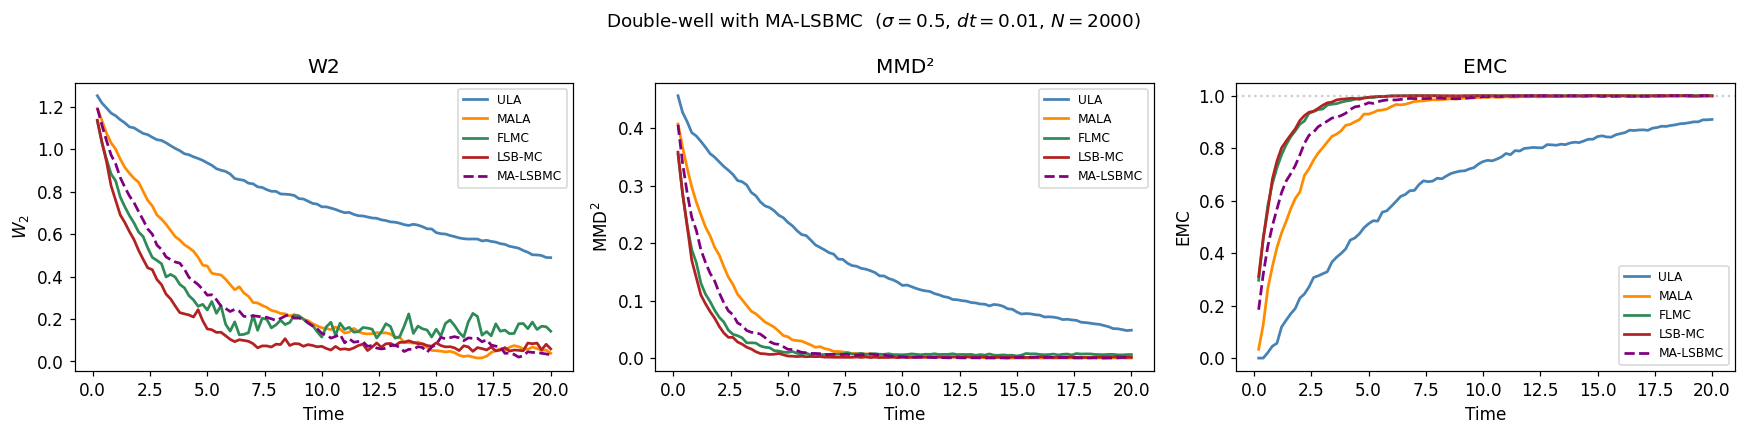

Saved to doublewell_output/doublewell_metrics_with_ma.{pdf,png}


In [19]:
# ── Color / method config for extended plots ────────────────────────────────
COLORS_EXT  = {**COLORS, 'MA-LSBMC': 'purple'}
METHODS_EXT = ['ULA', 'MALA', 'FLMC', 'LSB-MC', 'MA-LSBMC']


def _get_ext(m, idx):
    """Helper: safely index into results_ext tuple (7 or 6 elements)."""
    return results_ext[m][idx]


# ── Figure A: metric curves with MA-LSBMC ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for m in METHODS_EXT:
    t  = _get_ext(m, 0)
    w2 = _get_ext(m, 1)
    mm = _get_ext(m, 2)
    em = _get_ext(m, 3)
    ls = '--' if m == 'MA-LSBMC' else '-'
    axes[0].plot(t, w2, color=COLORS_EXT[m], lw=1.8, ls=ls, label=m)
    axes[1].plot(t, mm, color=COLORS_EXT[m], lw=1.8, ls=ls, label=m)
    axes[2].plot(t, em, color=COLORS_EXT[m], lw=1.8, ls=ls, label=m)

axes[0].set(xlabel='Time', ylabel='$W_2$',   title='W2')
axes[1].set(xlabel='Time', ylabel='MMD$^2$', title='MMD²')
axes[2].set(xlabel='Time', ylabel='EMC',     title='EMC')
axes[2].axhline(1.0, color='gray', ls=':', alpha=0.4)
for ax in axes:
    ax.legend(fontsize=8)

plt.suptitle(f'Double-well with MA-LSBMC  ($\\sigma={SIGMA}$, $dt={DT}$, $N={N_PART}$)',
             fontsize=12)
plt.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(OUT / f'doublewell_metrics_with_ma.{ext}', bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved to {OUT}/doublewell_metrics_with_ma.{{pdf,png}}")

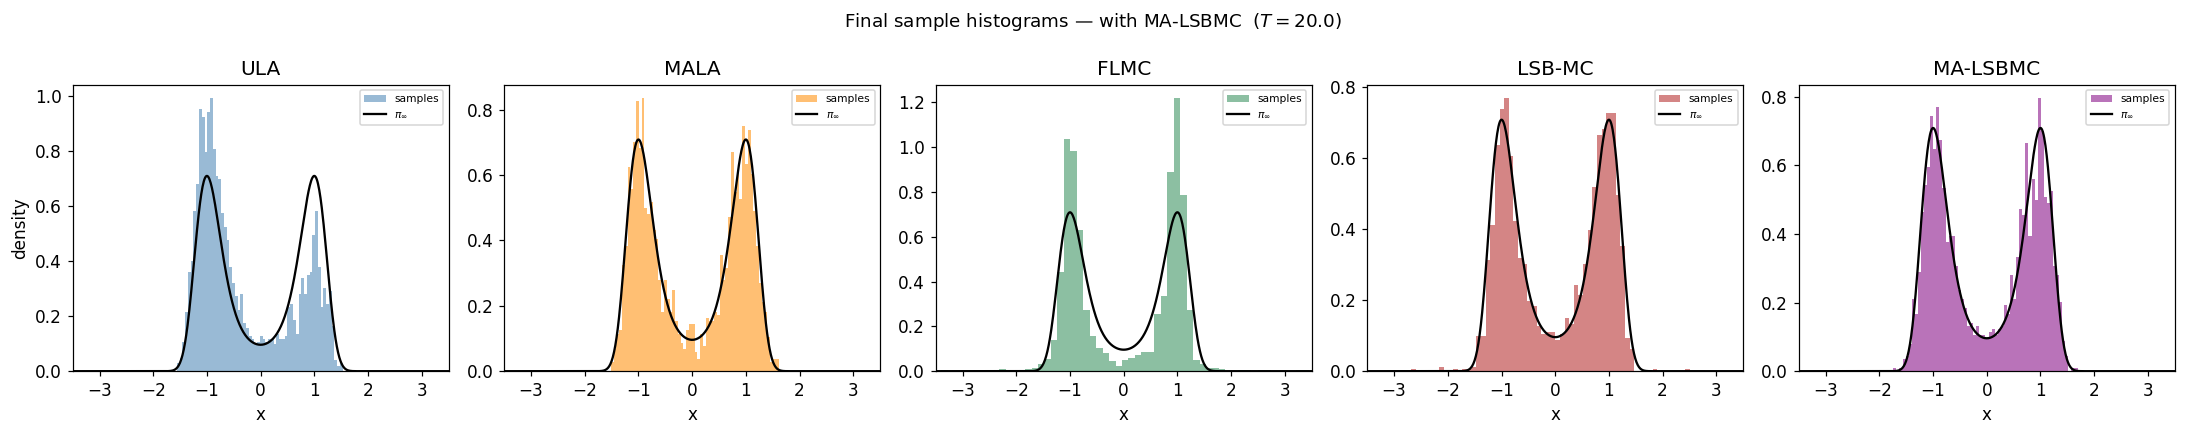

Saved to doublewell_output/doublewell_final_density_with_ma.{pdf,png}


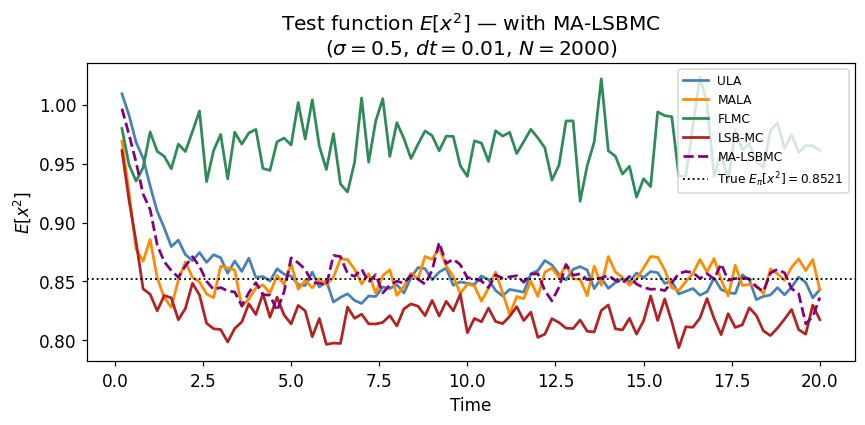

Saved to doublewell_output/doublewell_ex2_with_ma.{pdf,png}


In [20]:
# ── Figure B: final sample histograms with MA-LSBMC ────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=False)
xs_d2 = np.linspace(-3.5, 3.5, 600)
pi_v2 = target.density(xs_d2)

for ax, m in zip(axes, METHODS_EXT):
    x_fin = _get_ext(m, 5)
    ax.hist(_finite(x_fin), bins=60, density=True, alpha=0.55,
            color=COLORS_EXT[m], label='samples')
    ax.plot(xs_d2, pi_v2, 'k-', lw=1.5, label='$\\pi_\\infty$')
    ax.set(title=m, xlabel='x', xlim=(-3.5, 3.5))
    ax.legend(fontsize=7)

axes[0].set_ylabel('density')
plt.suptitle(f'Final sample histograms — with MA-LSBMC  ($T={T_TOTAL}$)', fontsize=12)
plt.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(OUT / f'doublewell_final_density_with_ma.{ext}', bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved to {OUT}/doublewell_final_density_with_ma.{{pdf,png}}")


# ── Figure C: E[x^2] with MA-LSBMC ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
for m in METHODS_EXT:
    t   = _get_ext(m, 0)
    ex2 = _get_ext(m, 4)
    ls  = '--' if m == 'MA-LSBMC' else '-'
    ax.plot(t, ex2, color=COLORS_EXT[m], lw=1.8, ls=ls, label=m)

ax.axhline(_true_ex2, color='black', ls=':', lw=1.2,
           label=f'True $E_{{\\pi}}[x^2]={_true_ex2:.4f}$')
ax.set(xlabel='Time', ylabel='$E[x^2]$',
       title=f'Test function $E[x^2]$ — with MA-LSBMC\n'
             f'($\\sigma={SIGMA}$, $dt={DT}$, $N={N_PART}$)')
ax.legend(fontsize=8)
plt.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(OUT / f'doublewell_ex2_with_ma.{ext}', bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved to {OUT}/doublewell_ex2_with_ma.{{pdf,png}}")